# 02 Routing Control

This notebook combines the routing-control quality and consistency CSVs into the main routing-control figure.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

QUALITY_PATH = RESULTS_ROOT / "02_routing_control/02a_routing_control_quality.csv"
CONSISTENCY_PATH = RESULTS_ROOT / "02_routing_control/02b_routing_control_consistency.csv"
QUALITY_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "metric", "cutoff", "value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]
CONSISTENCY_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "similarity_bucket", "consistency_value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]


def demo_quality() -> pd.DataFrame:
    rows = []
    datasets = ["Beauty", "Foursquare", "KuaiRec", "Retail Rocket"]
    variants = {
        "shared_ffn": [0.063, 0.109, 0.102, 0.201],
        "hidden_only": [0.069, 0.123, 0.110, 0.218],
        "mixed": [0.071, 0.129, 0.114, 0.224],
        "behavior_only": [0.076, 0.143, 0.119, 0.250],
    }
    for variant, values in variants.items():
        for dataset, value in zip(datasets, values):
            rows.append(
                {
                    "paper_section": "02_routing_control",
                    "panel": "quality",
                    "dataset": dataset,
                    "variant_or_model": variant,
                    "metric": "MRR",
                    "cutoff": 20,
                    "value": value,
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                }
            )
    return pd.DataFrame(rows)


def demo_consistency() -> pd.DataFrame:
    rows = []
    buckets = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
    variants = {
        "hidden_only": [0.31, 0.38, 0.44, 0.50, 0.56],
        "behavior_only": [0.35, 0.44, 0.53, 0.61, 0.69],
    }
    for variant, values in variants.items():
        for bucket, value in zip(buckets, values):
            rows.append(
                {
                    "paper_section": "02_routing_control",
                    "panel": "consistency",
                    "dataset": "aggregate",
                    "variant_or_model": variant,
                    "similarity_bucket": bucket,
                    "consistency_value": value,
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                }
            )
    return pd.DataFrame(rows)


In [2]:
quality_df, quality_mode = load_csv_or_demo(QUALITY_PATH, QUALITY_COLUMNS, demo_builder=demo_quality)
consistency_df, consistency_mode = load_csv_or_demo(CONSISTENCY_PATH, CONSISTENCY_COLUMNS, demo_builder=demo_consistency)
display(Markdown(f"**Load mode:** quality={quality_mode}, consistency={consistency_mode}"))
display(quality_df.head())
display(consistency_df.head())


**Load mode:** quality=demo, consistency=demo

,paper_section,panel,dataset,variant_or_model,metric,cutoff,value,split,selection_rule,run_id,source_path,notes
0,02_routing_control,quality,Beauty,shared_ffn,MRR,20,0.063,test,demo,demo,demo,demo data
1,02_routing_control,quality,Foursquare,shared_ffn,MRR,20,0.109,test,demo,demo,demo,demo data
2,02_routing_control,quality,KuaiRec,shared_ffn,MRR,20,0.102,test,demo,demo,demo,demo data
3,02_routing_control,quality,Retail Rocket,shared_ffn,MRR,20,0.201,test,demo,demo,demo,demo data
4,02_routing_control,quality,Beauty,hidden_only,MRR,20,0.069,test,demo,demo,demo,demo data


,paper_section,panel,dataset,variant_or_model,similarity_bucket,consistency_value,split,selection_rule,run_id,source_path,notes
0,02_routing_control,consistency,aggregate,hidden_only,0.0-0.2,0.31,test,demo,demo,demo,demo data
1,02_routing_control,consistency,aggregate,hidden_only,0.2-0.4,0.38,test,demo,demo,demo,demo data
2,02_routing_control,consistency,aggregate,hidden_only,0.4-0.6,0.44,test,demo,demo,demo,demo data
3,02_routing_control,consistency,aggregate,hidden_only,0.6-0.8,0.50,test,demo,demo,demo,demo data
4,02_routing_control,consistency,aggregate,hidden_only,0.8-1.0,0.56,test,demo,demo,demo,demo data


Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/02_routing_control.png, /workspace/FeaturedMoE/writing/results/generated_figures/02_routing_control.pdf

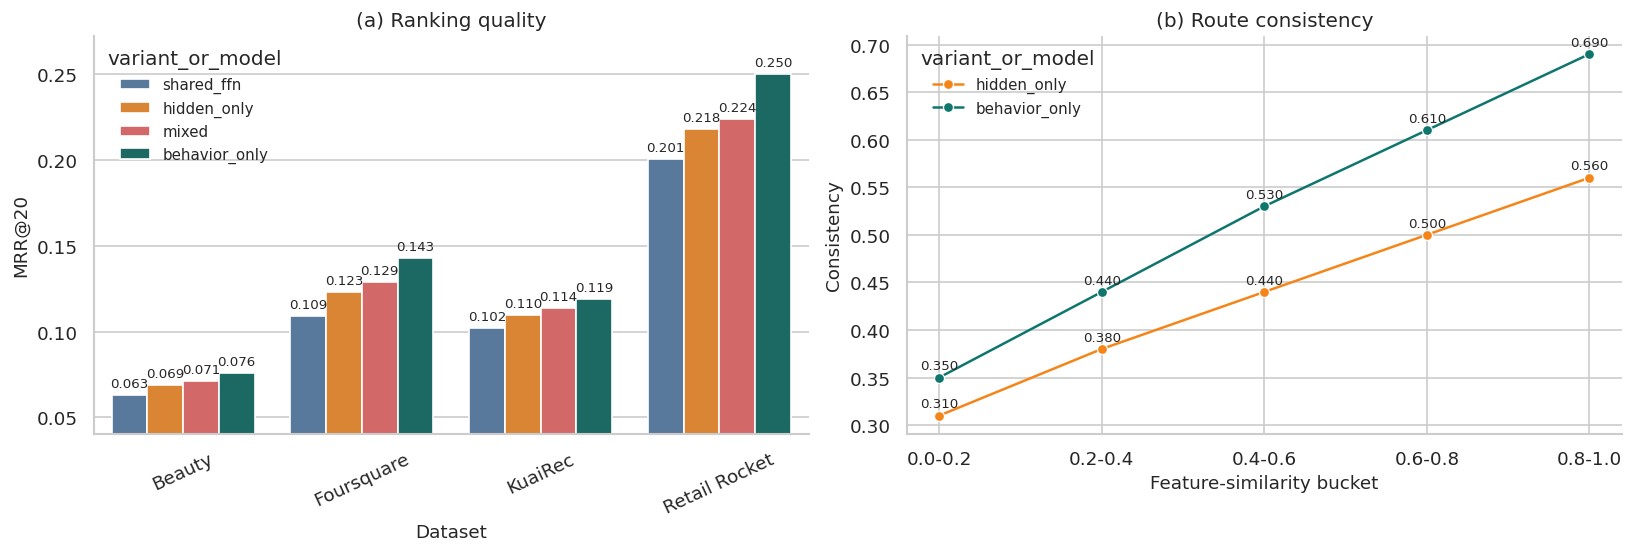

In [3]:
bucket_order = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
consistency_df = consistency_df.copy()
consistency_df["similarity_bucket"] = pd.Categorical(consistency_df["similarity_bucket"], categories=bucket_order, ordered=True)
consistency_df = consistency_df.sort_values("similarity_bucket")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)
grouped_barplot(
    quality_df,
    x="dataset",
    hue="variant_or_model",
    y="value",
    ax=axes[0],
    title="(a) Ranking quality",
    ylabel="MRR@20",
    xlabel="Dataset",
    rotate=25,
)
lineplot_with_markers(
    consistency_df,
    x="similarity_bucket",
    y="consistency_value",
    hue="variant_or_model",
    ax=axes[1],
    title="(b) Route consistency",
    ylabel="Consistency",
    xlabel="Feature-similarity bucket",
    annotate_points=True,
)
saved_paths = export_figure(fig, "02_routing_control", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
